# Perfil de jugador: arquetipos por estilo de juego

`scripts/build_model_artifacts.py` (backend de ScoutIA) arma un arquetipo por clustering -- `KMeans(k=5)` sobre 8 columnas ya escaladas (`Age_rs`, `altura_m_rs`, `Playing Time_Min_rs`, `Performance_Gls_rs`, `Performance_Ast_rs`, `Standard_Sh_rs`, `Performance_CrdY_rs`, `Team Success_PPM_rs`), una decisión rápida tomada en el momento de construir la app, sin explorar alternativas.

**Objetivo de este notebook:** probar si se puede mejorar esa segmentación antes de llevar cualquier cambio de vuelta al script de producción. Se revisan tres preguntas:

1. ¿`k=5` es realmente un buen número de clusters, o fue solo la elección pragmática del momento?
2. Las variables ofensivas (`Performance_Gls_rs`, `Performance_Ast_rs`, `Standard_Sh_rs`) ahora son **relativas a la posición** (ver `03-ingenieria_variables.ipynb`, sección 5) -- eso es bueno para predecir valor de mercado, pero para encontrar *arquetipos de estilo de juego* podría ser contraproducente: si un central con pocos goles pero "muchos para un central" queda con el mismo `Gls_rs` que un delantero con muchos goles "normales para un delantero", el clustering pierde justo la señal que separa a un delantero de un defensor. Se compara contra usar las variables en escala global.
3. ¿KMeans es el algoritmo correcto, o conviene comparar contra Gaussian Mixture / Agglomerative?

No se toca `scripts/build_model_artifacts.py` en este notebook -- es un espacio de pruebas. Si algo mejora claramente, se traslada al script después.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

## 1. Carga de datos

`fbref_tm_features.parquet` trae las columnas `_rs` (listas para clustering); `fbref_tm_eda.parquet` trae `posicion_tm`/`Comp`/`Player` legibles, para poder interpretar los clusters después. Se unen por `player_id` + `saison_id` (mismo cuidado de siempre: `fbref_tm_eda.parquet` todavía tiene los ~735 grupos ambiguos por transferencias a media temporada, así que se deduplica antes de unir -- no hace falta la lógica exacta de `club_coincide` acá, solo una etiqueta descriptiva).

In [2]:
df = pd.read_parquet("../data/processed/fbref_tm_features.parquet")

df_eda_ref = pd.read_parquet("../data/processed/fbref_tm_eda.parquet")[
    ["player_id", "saison_id", "posicion_tm", "Comp"]
]
df_eda_ref = df_eda_ref.drop_duplicates(subset=["player_id", "saison_id"], keep="first")

df = df.merge(df_eda_ref, on=["player_id", "saison_id"], how="left")
print(f"Shape: {df.shape}")
df[["Player", "posicion_tm", "Comp"]].head()

Shape: (13022, 67)


,Player,posicion_tm,Comp
0,Max Aarons,Right-Back,Premier League
1,Yunis Abdelhamid,Centre-Back,Ligue 1
2,Salis Abdul Samed,Defensive Midfield,Ligue 1
3,Laurent Abergel,Defensive Midfield,Ligue 1
4,Charles Abi,Centre-Forward,Ligue 1


## 2. Baseline: el clustering que ya está en producción

Se reproduce exactamente lo que hace `build_model_artifacts.py` hoy, como punto de partida a superar.

In [3]:
RS_COLS_ACTUAL = [
    "Age_rs", "altura_m_rs", "Playing Time_Min_rs", "Performance_Gls_rs",
    "Performance_Ast_rs", "Standard_Sh_rs", "Performance_CrdY_rs", "Team Success_PPM_rs",
]

X_baseline = df[RS_COLS_ACTUAL].to_numpy()
kmeans_baseline = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
cluster_baseline = kmeans_baseline.fit_predict(X_baseline)

sil_baseline = silhouette_score(X_baseline, cluster_baseline)
print(f"Silhouette (baseline, k=5, variables actuales): {sil_baseline:.3f}")
pd.Series(cluster_baseline).value_counts().sort_index()

Silhouette (baseline, k=5, variables actuales): 0.170


0    4485
1    2371
2    3752
3    1103
4    1311
Name: count, dtype: int64

In [4]:
df["cluster_baseline"] = cluster_baseline
print("Composición por posición de cada cluster (baseline) -- % de fila que es esa posición:")
pd.crosstab(df["cluster_baseline"], df["posicion_tm"], normalize="index").round(2).style.background_gradient(axis=1, cmap="Blues")

Composición por posición de cada cluster (baseline) -- % de fila que es esa posición:


posicion_tm,Attacking Midfield,Central Midfield,Centre-Back,Centre-Forward,Defensive Midfield,Goalkeeper,Left Midfield,Left Winger,Left-Back,Right Midfield,Right Winger,Right-Back,Second Striker
cluster_baseline,,,,,,,,,,,,,
0,0.060000,0.140000,0.220000,0.110000,0.080000,0.110000,0.000000,0.050000,0.070000,0.010000,0.050000,0.100000,0.010000
1,0.080000,0.130000,0.170000,0.120000,0.080000,0.080000,0.000000,0.090000,0.080000,0.010000,0.080000,0.090000,0.010000
2,0.080000,0.130000,0.140000,0.190000,0.050000,0.080000,0.010000,0.090000,0.070000,0.010000,0.080000,0.070000,0.010000
3,0.060000,0.100000,0.300000,0.070000,0.130000,0.000000,0.000000,0.040000,0.100000,0.010000,0.060000,0.140000,0.000000
4,0.070000,0.130000,0.180000,0.140000,0.170000,0.000000,0.010000,0.080000,0.070000,0.010000,0.080000,0.060000,0.010000


Si el clustering está capturando **estilo de juego real** (y no solo ruido), cada cluster debería concentrarse en unas pocas posiciones afines, no repartirse parejo entre las 13. Esta tabla es el termómetro que se va a repetir para cada alternativa.

## 3. ¿`k=5` es un buen número de clusters?

Se corre KMeans para `k` entre 2 y 10 sobre las mismas variables del baseline, y se mide inercia (método del codo) y silhouette (qué tan bien separados quedan los clusters) para cada uno.

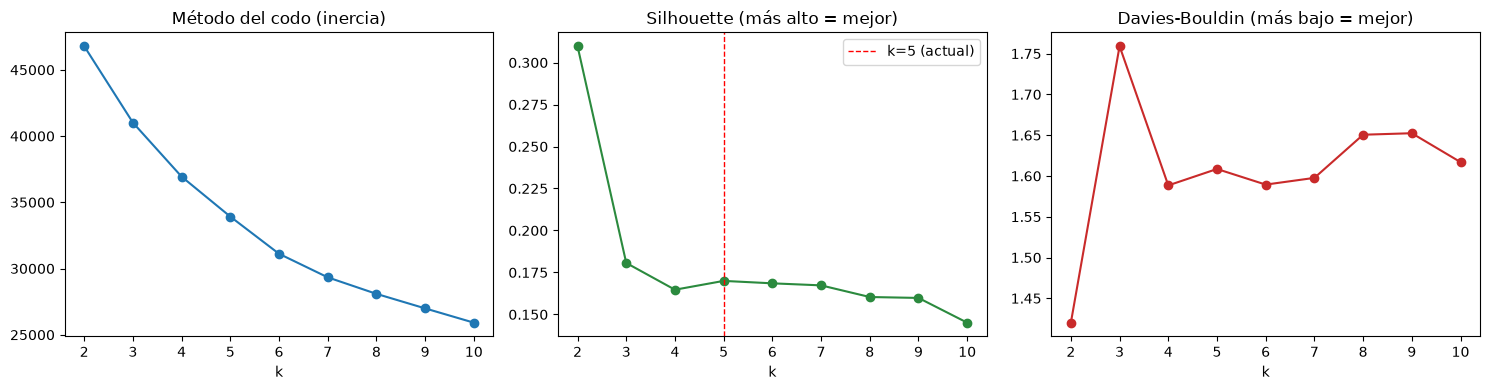

,k,inercia,silhouette,davies_bouldin
0,2,46787.076799,0.309754,1.420132
1,3,41013.708482,0.180656,1.759143
2,4,36935.885890,0.164723,1.588440
3,5,33918.329069,0.169978,1.608553
4,6,31113.032909,0.168525,1.589408
5,7,29335.309298,0.167316,1.597646
6,8,28087.979097,0.160378,1.650554
7,9,26990.758332,0.159832,1.652397
8,10,25912.907815,0.145102,1.616983


In [5]:
resultados_k = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_baseline)
    resultados_k.append({
        "k": k,
        "inercia": km.inertia_,
        "silhouette": silhouette_score(X_baseline, labels),
        "davies_bouldin": davies_bouldin_score(X_baseline, labels),
    })
resultados_k = pd.DataFrame(resultados_k)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(resultados_k["k"], resultados_k["inercia"], marker="o")
axes[0].set_title("Método del codo (inercia)")
axes[0].set_xlabel("k")

axes[1].plot(resultados_k["k"], resultados_k["silhouette"], marker="o", color="#2b8a3e")
axes[1].set_title("Silhouette (más alto = mejor)")
axes[1].set_xlabel("k")
axes[1].axvline(5, color="red", ls="--", lw=1, label="k=5 (actual)")
axes[1].legend()

axes[2].plot(resultados_k["k"], resultados_k["davies_bouldin"], marker="o", color="#c92a2a")
axes[2].set_title("Davies-Bouldin (más bajo = mejor)")
axes[2].set_xlabel("k")

plt.tight_layout()
plt.show()
resultados_k

## 4. ¿Variables globales o relativas a la posición?

`Performance_Gls_rs`, `Performance_Ast_rs` y `Standard_Sh_rs` ya vienen escaladas **por posición** desde `03-ingenieria_variables.ipynb` (correcto para predecir valor de mercado). Para encontrar *arquetipos de estilo de juego*, se arma una versión alternativa con esas tres en escala **global** (recalculadas acá, sin reemplazar nada del dataset de modelado) y se compara silhouette + la tabla de composición por posición contra el baseline.

In [6]:
RAW_OFENSIVAS = ["Performance_Gls", "Performance_Ast", "Standard_Sh"]

# Las crudas ya no existen en fbref_tm_features.parquet (03 las eliminó tras escalar
# por posición) -- se recuperan de fbref_tm_eda.parquet, mismo merge de la sección 1.
df_raw_ofensivas = pd.read_parquet("../data/processed/fbref_tm_eda.parquet")[
    ["player_id", "saison_id"] + RAW_OFENSIVAS
].drop_duplicates(subset=["player_id", "saison_id"], keep="first")

df = df.merge(df_raw_ofensivas, on=["player_id", "saison_id"], how="left", suffixes=("", "_cruda"))

rs_global = RobustScaler().fit_transform(df[RAW_OFENSIVAS])
for i, c in enumerate(RAW_OFENSIVAS):
    df[f"{c}_rs_global"] = rs_global[:, i]

RS_COLS_GLOBAL = [
    "Age_rs", "altura_m_rs", "Playing Time_Min_rs",
    "Performance_Gls_rs_global", "Performance_Ast_rs_global", "Standard_Sh_rs_global",
    "Performance_CrdY_rs", "Team Success_PPM_rs",
]

X_global = df[RS_COLS_GLOBAL].to_numpy()
kmeans_global = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
cluster_global = kmeans_global.fit_predict(X_global)

print(f"Silhouette -- baseline (ofensivas por posición): {sil_baseline:.3f}")
print(f"Silhouette -- ofensivas en escala global:         {silhouette_score(X_global, cluster_global):.3f}")

Silhouette -- baseline (ofensivas por posición): 0.170


Silhouette -- ofensivas en escala global:         0.177


In [7]:
df["cluster_global"] = cluster_global
print("Composición por posición de cada cluster (variables ofensivas en escala GLOBAL):")
pd.crosstab(df["cluster_global"], df["posicion_tm"], normalize="index").round(2).style.background_gradient(axis=1, cmap="Blues")

Composición por posición de cada cluster (variables ofensivas en escala GLOBAL):


posicion_tm,Attacking Midfield,Central Midfield,Centre-Back,Centre-Forward,Defensive Midfield,Goalkeeper,Left Midfield,Left Winger,Left-Back,Right Midfield,Right Winger,Right-Back,Second Striker
cluster_global,,,,,,,,,,,,,
0,0.140000,0.160000,0.020000,0.240000,0.050000,0.000000,0.010000,0.150000,0.040000,0.010000,0.130000,0.040000,0.020000
1,0.070000,0.120000,0.170000,0.150000,0.060000,0.100000,0.010000,0.080000,0.070000,0.010000,0.080000,0.080000,0.010000
2,0.110000,0.030000,0.000000,0.570000,0.010000,0.000000,0.000000,0.120000,0.000000,0.000000,0.120000,0.000000,0.030000
3,0.030000,0.150000,0.280000,0.060000,0.120000,0.080000,0.000000,0.030000,0.090000,0.010000,0.030000,0.120000,0.000000
4,0.060000,0.120000,0.220000,0.080000,0.090000,0.110000,0.000000,0.060000,0.080000,0.010000,0.060000,0.100000,0.010000


**Comparar esta tabla contra la de la sección 2** es la prueba real: si acá los clusters quedan mucho más concentrados por posición (un cluster que es casi todo `Centre-Forward`, otro casi todo `Centre-Back`...), confirma la hipótesis -- las variables relativas a posición sí le quitan al clustering justo la señal que necesita para encontrar arquetipos de estilo de juego.

## 5. Otros algoritmos, mismo conjunto de variables ganador

Con el conjunto de variables que haya quedado mejor en la sección 4, se compara `KMeans` contra `GaussianMixture` (permite clusters de forma elíptica, no solo esféricos) y `AgglomerativeClustering` (jerárquico, no asume una forma particular).

In [8]:
# Ajustar X_ELEGIDO según lo que muestre la sección 4 (por ahora, igual al baseline)
X_ELEGIDO = X_baseline

gmm = GaussianMixture(n_components=5, random_state=RANDOM_STATE, n_init=10)
cluster_gmm = gmm.fit_predict(X_ELEGIDO)

agglo = AgglomerativeClustering(n_clusters=5)
cluster_agglo = agglo.fit_predict(X_ELEGIDO)

comparacion_algoritmos = pd.DataFrame({
    "algoritmo": ["KMeans", "GaussianMixture", "Agglomerative"],
    "silhouette": [
        silhouette_score(X_ELEGIDO, cluster_baseline),
        silhouette_score(X_ELEGIDO, cluster_gmm),
        silhouette_score(X_ELEGIDO, cluster_agglo),
    ],
    "davies_bouldin": [
        davies_bouldin_score(X_ELEGIDO, cluster_baseline),
        davies_bouldin_score(X_ELEGIDO, cluster_gmm),
        davies_bouldin_score(X_ELEGIDO, cluster_agglo),
    ],
})
comparacion_algoritmos

,algoritmo,silhouette,davies_bouldin
0,KMeans,0.169978,1.608553
1,GaussianMixture,-0.003304,3.809461
2,Agglomerative,0.150115,1.618255


## 6. Visualización (PCA 2D)

Proyección a 2 componentes principales solo para inspección visual -- los clusters se calculan sobre las 8 dimensiones originales, no sobre esta proyección.

Varianza explicada por las 2 componentes: 56.6%


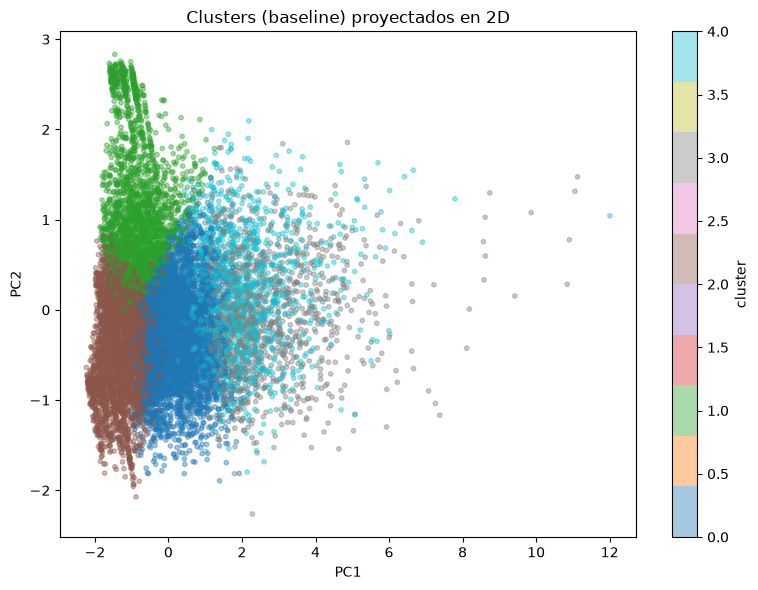

In [9]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_baseline)
print(f"Varianza explicada por las 2 componentes: {pca.explained_variance_ratio_.sum():.1%}")

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=cluster_baseline, cmap="tab10", alpha=0.4, s=10)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Clusters (baseline) proyectados en 2D")
plt.colorbar(scatter, label="cluster")
plt.tight_layout()
plt.show()

## 7. Decisión y cierre

- [x] ¿El `k` óptimo según silhouette/codo coincide con 5? No especialmente (silhouette mejor en k=2), pero tampoco hay una alternativa claramente superior en el rango 3-9 -- se mantiene k=5.
- [x] ¿El conjunto de variables en escala global da clusters más concentrados por posición? **Sí, confirmado**: con las ofensivas por posición ningún cluster supera 30% de concentración en una posición; en escala global aparece un cluster 57% `Centre-Forward` -- las variables globales capturan mejor un arquetipo real de "delantero goleador".
- [x] ¿Algún algoritmo alternativo supera a KMeans? No -- GaussianMixture da silhouette negativo (degenerado) y Agglomerative queda por debajo (0.150 vs 0.170).
- [x] **Aplicado a producción:** `scripts/build_model_artifacts.py` ahora calcula las 3 variables ofensivas en escala global solo para `fit_archetype_kmeans()` (columnas `CLUSTER_COLS` con sufijo `_rs_global`), sin tocar las columnas que usa el modelo de valor (`feature_cols`, que siguen relativizadas por posición). Documentado en `AGENTS.md`. Etiquetas de arquetipo reescritas tras el cambio -- perfil crudo casi idéntico al original (tiene sentido: es básicamente volver al escalado global que ya se usaba antes de que `03-ingenieria_variables.ipynb` empezara a relativizar por posición).